In [2]:
import dataset
import pandas as pd

# Looking at routes

In [6]:
# Need route buckets
df = pd.DataFrame()
for month in range(1, 13):
    tmp = dataset.clean_single_month(month=month)
    agg = tmp.groupby(['route'], as_index=False, observed=True).agg(
        total_rides = ('route', 'count'), 
        total_fares = ('fare_amount', 'sum'),
        total_revenue = ('total_amount', 'sum'),
        total_passenger_count = ('passenger_count', 'sum'),
        total_trip_distance = ('trip_distance', 'sum'),
    )
    df = pd.concat([df, agg], ignore_index=True)

df = df.groupby(['route'], as_index=False)[['total_rides', 'total_fares', 'total_revenue', 'total_passenger_count', 'total_trip_distance']].sum()
df = df.astype({'route': 'category'})
df

,route,total_rides,total_fares,total_revenue,total_passenger_count,total_trip_distance
0,Alphabet City to Allerton/Pelham Gardens,3,139.50,149.94,3.0,42.50
1,Alphabet City to Alphabet City,924,10656.58,16447.06,921.0,597.06
2,Alphabet City to Astoria,58,2028.98,2762.10,70.0,444.57
3,Alphabet City to Baisley Park,1,45.50,52.94,1.0,14.10
4,Alphabet City to Battery Park,10,178.61,233.05,9.0,34.66
...,...,...,...,...,...,...
15351,Yorkville West to Woodside,283,7277.77,9635.97,360.0,1450.06
15352,Yorkville West to World Trade Center,1072,35850.23,44703.58,837.0,8331.92
15353,Yorkville West to Yorkville East,32014,215668.93,421690.34,39131.0,21552.26
15354,Yorkville West to Yorkville West,37102,257846.96,492177.91,45445.0,113830.94


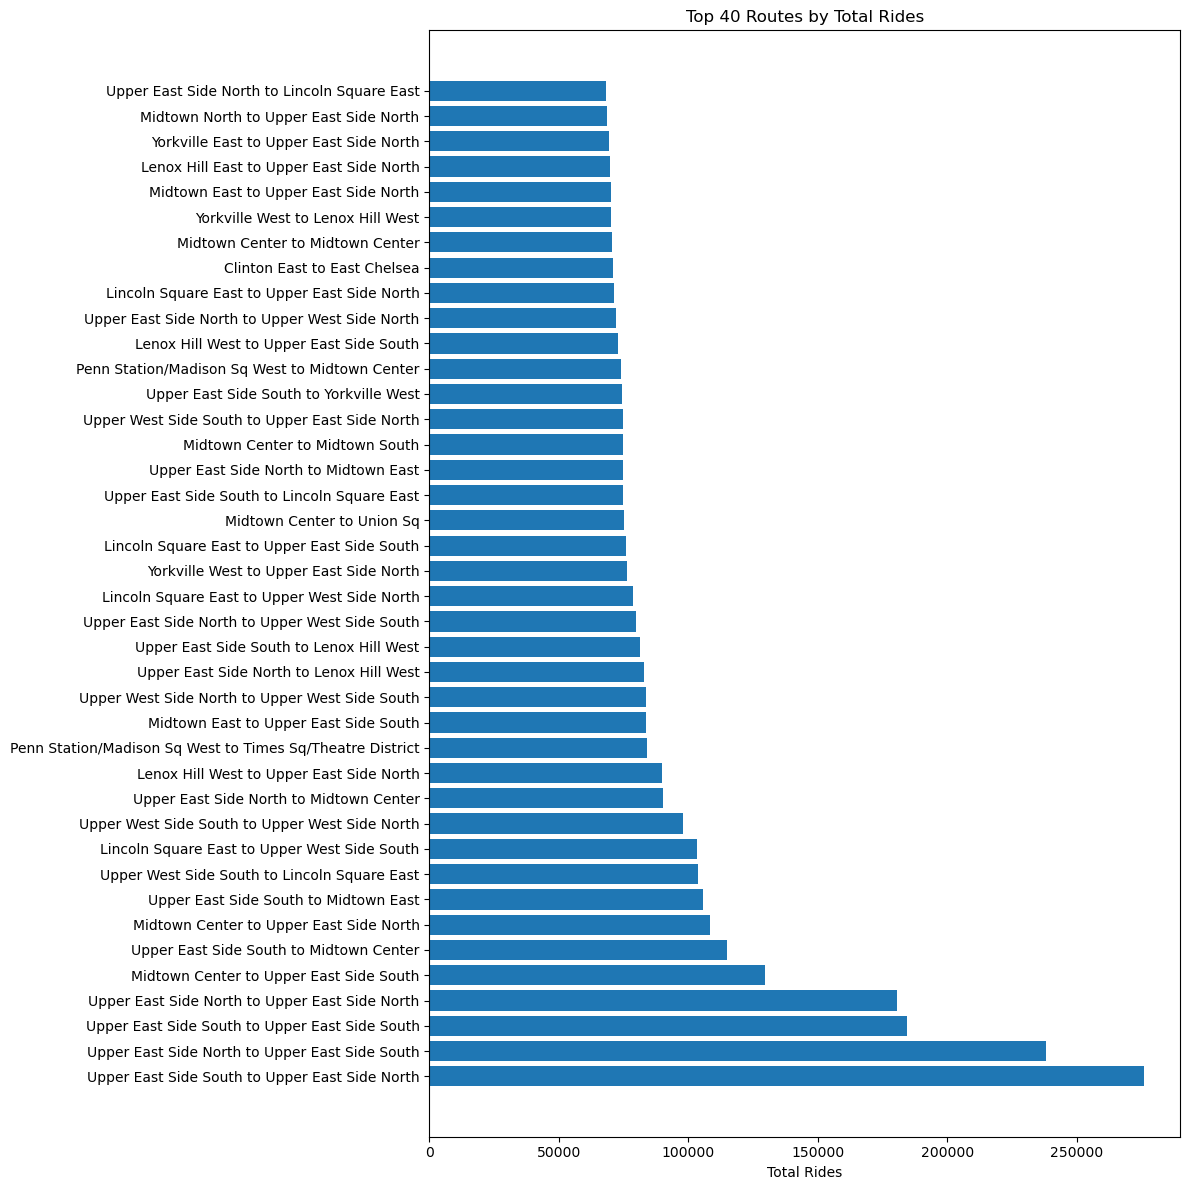

In [58]:
import matplotlib.pyplot as plt

top10 = df.nlargest(40, 'total_rides')

plt.figure(figsize=(12,12))
plt.barh(top10['route'], top10['total_rides'])
plt.title('Top 40 Routes by Total Rides')
plt.xlabel('Total Rides')
plt.tight_layout()
plt.show()

In [3]:
data = dataset.read_agg(month_start=1, month_end=12)
data.head(3)

reading data for month 1
reading data for month 2
reading data for month 3
reading data for month 4
reading data for month 5
reading data for month 6
reading data for month 7
reading data for month 8
reading data for month 9
reading data for month 10
reading data for month 11
reading data for month 12
collecting weather data


/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:296: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('T', 0, inplace=True)
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:297: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wthr.replace('M', np.nan, inplace=True)


collecting calendar data


,pickup_month,pickup_week,pickup_date,pickup_dow,time_of_day,route,vendor,total_ride_count,total_passenger_count,avg_passenger_count,...,snow,max_wind_speed,cloud_coverage,fog,low_vis,thunder,hail,freezing_rain,haze,holiday
0,1,1,2024-01-01,0,Evening,Alphabet City to Gramercy,"Curb Mobility, LLC",1,1.0,1.0,...,0.0,9.0,7.0,False,False,False,False,False,False,New Year's Day
1,1,1,2024-01-01,0,Evening,Alphabet City to Meatpacking/West Village West,"Creative Mobile Technologies, LLC",1,2.0,2.0,...,0.0,9.0,7.0,False,False,False,False,False,False,New Year's Day
2,1,1,2024-01-01,0,Evening,Alphabet City to Penn Station/Madison Sq West,"Curb Mobility, LLC",1,0.0,NaN,...,0.0,9.0,7.0,False,False,False,False,False,False,New Year's Day


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483603 entries, 0 to 7483602
Data columns (total 40 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   pickup_month           int32         
 1   pickup_week            UInt32        
 2   pickup_date            datetime64[ns]
 3   pickup_dow             int32         
 4   time_of_day            object        
 5   route                  object        
 6   vendor                 object        
 7   total_ride_count       int64         
 8   total_passenger_count  float64       
 9   avg_passenger_count    float64       
 10  total_trip_distance    float64       
 11  avg_trip_distance      float64       
 12  total_fare_amount      float64       
 13  avg_fare_amount        float64       
 14  total_extra            float64       
 15  avg_extra              float64       
 16  total_mta_tax          float64       
 17  avg_mta_tax            float64       
 18  total_tip_amount      

In [ ]:
# Define ordering so lag goes in the right direction
tod_order = ['Late Night', 'Morning Rush', 'Midday', 'Evening Rush', 'Evening']
data['tod_rank'] = data['time_of_day'].map({v: i for i, v in enumerate(tod_order)})

# Sort so lag shift is correct
data = data.sort_values(['route', 'pickup_date', 'tod_rank'])

# Lag total_revenue by previous time-of-day window, per route
data['lag_revenue'] = (
    data.groupby(['route', 'pickup_date'])['total_ride_count']
    .shift(1)
)

data[data['route'] == "Upper East Side North to Upper East Side South"][['route', 'pickup_date', 'vendor', 'total_revenue']].head(20)